In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_DIR = Path("../data/raw")

well_files = sorted(DATA_DIR.glob("USROP*.csv"))

print("Number of well files:", len(well_files))

for file in well_files:
    print(file.name)

Number of well files: 7
USROP_A 0 N-NA_F-9_Ad.csv
USROP_A 1 N-S_F-7d.csv
USROP_A 2 N-SH_F-14d.csv
USROP_A 3 N-SH-F-15d.csv
USROP_A 4 N-SH_F-15Sd.csv
USROP_A 5 N-SH-F-5d.csv
USROP_A 6 N-SH_F-9d.csv


In [4]:
well_datasets = []

for well_id, file in enumerate(well_files):
    well_df = pd.read_csv(file)

    well_df["well_id"] = well_id
    well_df["source_file"] = file.name

    well_datasets.append(well_df)

complete_df = pd.concat(
    well_datasets,
    ignore_index=True
)

In [5]:
print("Combined shape:", complete_df.shape)

display(
    complete_df.groupby("well_id").size()
)

display(complete_df.head())

print(complete_df.columns.tolist())

Combined shape: (198928, 15)


well_id
0    13746
1     6389
2    47645
3    53041
4    51708
5    18548
6     7851
dtype: int64

,Unnamed: 0,Measured Depth m,Weight on Bit kkgf,Average Standpipe Pressure kPa,Average Surface Torque kN.m,Rate of Penetration m/h,Average Rotary Speed rpm,Mud Flow In L/min,Mud Density In g/cm3,Diameter mm,Average Hookload kkgf,Hole Depth (TVD) m,USROP Gamma gAPI,well_id,source_file
0,0,491.033,5.842270,9440.922214,0.244047,42.864024,84.0,2784.321942,1.21,311.15,93.780222,490.760309,150.88,0,USROP_A 0 N-NA_F-9_Ad.csv
1,1,491.185,6.241431,9499.941336,0.244047,42.315384,84.0,2784.321942,1.21,311.15,93.979803,490.910880,150.88,0,USROP_A 0 N-NA_F-9_Ad.csv
2,2,491.222,6.241431,9499.941336,0.244047,42.315384,84.0,2784.321942,1.21,311.15,93.979803,490.910880,150.88,0,USROP_A 0 N-NA_F-9_Ad.csv
3,3,491.338,6.368437,9313.024466,0.216931,42.894504,84.0,2784.321942,1.21,311.15,94.079593,491.061756,146.26,0,USROP_A 0 N-NA_F-9_Ad.csv
4,4,491.341,6.368437,9313.024466,0.216931,42.894504,84.0,2784.321942,1.21,311.15,94.079593,491.061756,146.26,0,USROP_A 0 N-NA_F-9_Ad.csv


['Unnamed: 0', 'Measured Depth m', 'Weight on Bit kkgf', 'Average Standpipe Pressure kPa', 'Average Surface Torque kN.m', 'Rate of Penetration m/h', 'Average Rotary Speed rpm', 'Mud Flow In L/min', 'Mud Density In g/cm3', 'Diameter mm', 'Average Hookload kkgf', 'Hole Depth (TVD) m', 'USROP Gamma gAPI', 'well_id', 'source_file']


In [6]:
# We expect exactly seven oil-well files
assert len(well_files) == 7, (
    f"Expected 7 well files, but found {len(well_files)}"
)

print("Total observations:", len(complete_df))
print("Total columns:", complete_df.shape[1])
print("Number of wells:", complete_df["well_id"].nunique())

Total observations: 198928
Total columns: 15
Number of wells: 7


In [7]:
well_summary = (
    complete_df
    .groupby(["well_id", "source_file"])
    .size()
    .reset_index(name="number_of_rows")
)

well_summary

,well_id,source_file,number_of_rows
0,0,USROP_A 0 N-NA_F-9_Ad.csv,13746
1,1,USROP_A 1 N-S_F-7d.csv,6389
2,2,USROP_A 2 N-SH_F-14d.csv,47645
3,3,USROP_A 3 N-SH-F-15d.csv,53041
4,4,USROP_A 4 N-SH_F-15Sd.csv,51708
5,5,USROP_A 5 N-SH-F-5d.csv,18548
6,6,USROP_A 6 N-SH_F-9d.csv,7851


In [8]:
data_audit = pd.DataFrame({
    "data_type": complete_df.dtypes,
    "missing_values": complete_df.isna().sum(),
    "missing_percentage": (
        complete_df.isna().mean() * 100
    ).round(2),
    "unique_values": complete_df.nunique()
})

data_audit

,data_type,missing_values,missing_percentage,unique_values
Unnamed: 0,int64,0,0.0,53041
Measured Depth m,float64,0,0.0,172077
Weight on Bit kkgf,float64,0,0.0,12296
Average Standpipe Pressure kPa,float64,0,0.0,31849
Average Surface Torque kN.m,float64,0,0.0,11008
Rate of Penetration m/h,float64,0,0.0,13613
Average Rotary Speed rpm,float64,0,0.0,5566
Mud Flow In L/min,float64,0,0.0,3798
Mud Density In g/cm3,float64,0,0.0,51
Diameter mm,float64,0,0.0,3


In [14]:
print(well_summary)
print(complete_df.columns.tolist())
data_audit

   well_id                source_file  number_of_rows
0        0  USROP_A 0 N-NA_F-9_Ad.csv           13746
1        1     USROP_A 1 N-S_F-7d.csv            6389
2        2   USROP_A 2 N-SH_F-14d.csv           47645
3        3   USROP_A 3 N-SH-F-15d.csv           53041
4        4  USROP_A 4 N-SH_F-15Sd.csv           51708
5        5    USROP_A 5 N-SH-F-5d.csv           18548
6        6    USROP_A 6 N-SH_F-9d.csv            7851
['Unnamed: 0', 'Measured Depth m', 'Weight on Bit kkgf', 'Average Standpipe Pressure kPa', 'Average Surface Torque kN.m', 'Rate of Penetration m/h', 'Average Rotary Speed rpm', 'Mud Flow In L/min', 'Mud Density In g/cm3', 'Diameter mm', 'Average Hookload kkgf', 'Hole Depth (TVD) m', 'USROP Gamma gAPI', 'well_id', 'source_file']


,data_type,missing_values,missing_percentage,unique_values
Unnamed: 0,int64,0,0.0,53041
Measured Depth m,float64,0,0.0,172077
Weight on Bit kkgf,float64,0,0.0,12296
Average Standpipe Pressure kPa,float64,0,0.0,31849
Average Surface Torque kN.m,float64,0,0.0,11008
Rate of Penetration m/h,float64,0,0.0,13613
Average Rotary Speed rpm,float64,0,0.0,5566
Mud Flow In L/min,float64,0,0.0,3798
Mud Density In g/cm3,float64,0,0.0,51
Diameter mm,float64,0,0.0,3


In [ ]:
#TOTAL NUMBER OF ROWS IN THE DATSET
well_summary['number_of_rows'].sum()

np.int64(198928)

| Column              | Simple meaning                                | Role                |
| ------------------- | --------------------------------------------- | ------------------- |
| Measured Depth      | Total distance travelled along the well path  | WELLcontext        |
| Hole Depth (TVD)    | Vertical distance below the surface           | Wellcontext        |
| Weight on Bit       | How strongly the bit is pushed into the rock  | Controllable        |
| Rotary Speed        | How quickly the drill rotates                 | Controllable        |
| Mud Flow In         | How much drilling fluid is pumped             | Controllable        |
| Mud Density         | How heavy the drilling fluid is               | Operating condition |
| Standpipe Pressure  | Pressure required to circulate drilling fluid | System response     |
| Surface Torque      | Resistance against drill rotation             | System response     |
| Hookload            | Weight carried by the rig’s hook              | System response     |
| Diameter            | Size of the drilled hole                      | Well design         |
| Gamma               | Signal indicating changes in rock/formation   | Formation context   |
| Rate of Penetration | Drilling speed in metres/hour                 | **Target**          |


In [18]:
working_df = complete_df.drop(
    columns=["Unnamed: 0"]
).copy()

In [19]:
working_df = working_df.rename(columns={
    "Measured Depth m": "measured_depth_m",
    "Weight on Bit kkgf": "wob_kkgf",
    "Average Standpipe Pressure kPa": "standpipe_pressure_kpa",
    "Average Surface Torque kN.m": "surface_torque_knm",
    "Rate of Penetration m/h": "rop_mph",
    "Average Rotary Speed rpm": "rotary_speed_rpm",
    "Mud Flow In L/min": "mud_flow_lpm",
    "Mud Density In g/cm3": "mud_density_gcm3",
    "Diameter mm": "diameter_mm",
    "Average Hookload kkgf": "hookload_kkgf",
    "Hole Depth (TVD) m": "tvd_m",
    "USROP Gamma gAPI": "gamma_gapi"
})

In [22]:
working_df.columns

Index(['measured_depth_m', 'wob_kkgf', 'standpipe_pressure_kpa',
       'surface_torque_knm', 'rop_mph', 'rotary_speed_rpm', 'mud_flow_lpm',
       'mud_density_gcm3', 'diameter_mm', 'hookload_kkgf', 'tvd_m',
       'gamma_gapi', 'well_id', 'source_file'],
      dtype='str')

In [23]:
working_df.isna().sum()

measured_depth_m          0
wob_kkgf                  0
standpipe_pressure_kpa    0
surface_torque_knm        0
rop_mph                   0
rotary_speed_rpm          0
mud_flow_lpm              0
mud_density_gcm3          0
diameter_mm               0
hookload_kkgf             0
tvd_m                     0
gamma_gapi                0
well_id                   0
source_file               0
dtype: int64

In [24]:
working_df.describe().T

,count,mean,std,min,25%,50%,75%,max
measured_depth_m,198928.0,2411.781370,1066.443448,225.171000,1548.686750,2697.182500,3288.946500,4090.001000
wob_kkgf,198928.0,6.087997,3.957126,0.001814,3.283486,5.190356,8.127138,31.411272
standpipe_pressure_kpa,198928.0,17451.302922,4236.531326,1432.661618,14655.999757,16683.999633,21153.529061,24998.459413
surface_torque_knm,198928.0,14.430343,7.239629,0.008135,9.639866,12.798921,17.815448,36.489128
rop_mph,198928.0,24.978426,15.086731,0.330000,12.990000,21.090000,32.470001,99.206304
rotary_speed_rpm,198928.0,152.368019,49.998842,0.000000,129.250000,139.736000,179.283000,311.230011
mud_flow_lpm,198928.0,2873.576072,1055.406219,185.420836,1993.927917,2121.382739,3987.855834,4538.450195
mud_density_gcm3,198928.0,4.008286,4.496288,1.020000,1.300000,1.350000,10.849026,12.017384
diameter_mm,198928.0,297.470693,100.344171,215.900000,215.900000,215.900000,444.500000,444.500000
hookload_kkgf,198928.0,127.503708,15.551890,84.047945,124.925435,130.905851,138.719433,152.926842


In [25]:
missing_summary = pd.DataFrame({
    "missing_count": working_df.isna().sum(),
    "missing_percentage": (
        working_df.isna().mean() * 100
    ).round(2)
})

missing_summary

,missing_count,missing_percentage
measured_depth_m,0,0.0
wob_kkgf,0,0.0
standpipe_pressure_kpa,0,0.0
surface_torque_knm,0,0.0
rop_mph,0,0.0
rotary_speed_rpm,0,0.0
mud_flow_lpm,0,0.0
mud_density_gcm3,0,0.0
diameter_mm,0,0.0
hookload_kkgf,0,0.0


In [27]:
measurement_columns = working_df.columns.difference(
    ["source_file"]
)
print(measurement_columns)
duplicate_count = working_df.duplicated(
    subset=measurement_columns
).sum()

print("Duplicate rows:", duplicate_count)

Index(['diameter_mm', 'gamma_gapi', 'hookload_kkgf', 'measured_depth_m',
       'mud_density_gcm3', 'mud_flow_lpm', 'rop_mph', 'rotary_speed_rpm',
       'standpipe_pressure_kpa', 'surface_torque_knm', 'tvd_m', 'well_id',
       'wob_kkgf'],
      dtype='str')
Duplicate rows: 4


# Domain checks :

In [ ]:
domain_checks = pd.Series({
    "TVD greater than measured depth": (
        working_df["tvd_m"] >
        working_df["measured_depth_m"]
    ).sum(),

    "Measured depth below zero": (
        working_df["measured_depth_m"] < 0
    ).sum(),

    "WOB below zero": (
        working_df["wob_kkgf"] < 0
    ).sum(),

    "WOB above 35": (
        working_df["wob_kkgf"] > 35
    ).sum(),

    "ROP below zero": (
        working_df["rop_mph"] < 0
    ).sum(),

    "ROP above 100": (
        working_df["rop_mph"] > 100
    ).sum(),

    "Negative mud flow": (
        working_df["mud_flow_lpm"] < 0
    ).sum(),

    "Negative mud density": (
        working_df["mud_density_gcm3"] < 0
    ).sum(),

    "Negative surface torque": (
        working_df["surface_torque_knm"] < 0
    ).sum(),

    "Negative standpipe pressure": (
        working_df["standpipe_pressure_kpa"] < 0
    ).sum(),

    "Standpipe pressure above 25000": (
        working_df["standpipe_pressure_kpa"] > 25_000
    ).sum(),

    "Negative rotary speed": (
        working_df["rotary_speed_rpm"] < 0
    ).sum(),

    "Non-positive diameter": (
        working_df["diameter_mm"] <= 0
    ).sum(),

    "Negative hookload": (
        working_df["hookload_kkgf"] < 0
    ).sum()
})

domain_checks
#In general geometrically the TVD(verticl distance )normlally should not exceed measured depth when both use the same reference point. However, this could result from:
#

TVD greater than measured depth    472
Measured depth below zero            0
WOB below zero                       0
WOB above 35                         0
ROP below zero                       0
ROP above 100                        0
Negative mud flow                    0
Negative mud density                 0
Negative surface torque              0
Negative standpipe pressure          0
Standpipe pressure above 25000       0
Negative rotary speed                0
Non-positive diameter                0
Negative hookload                    0
dtype: int64

| Check                           | Reason                                                                            |
| ------------------------------- | --------------------------------------------------------------------------------- |
| `TVD ≤ measured depth`          | Vertical distance cannot exceed the complete distance travelled along the well    |
| Depth should generally increase | These are depth-based drilling logs                                               |
| `WOB ≥ 0`                       | Negative force on the bit is suspicious                                           |
| `WOB ≤ 35 kkgf`                 | Dataset-specific boundary documented in the paper                                 |
| `ROP ≥ 0`                       | Negative drilling speed is physically inconsistent here                           |
| `ROP ≤ 100 m/h`                 | Dataset-specific boundary documented in the paper                                 |
| Mud flow ≥ 0                    | Negative incoming flow is impossible                                              |
| Mud density ≥ 0                 | Negative fluid density is impossible                                              |
| Surface torque ≥ 0              | Negative values are inconsistent with this dataset definition                     |
| Standpipe pressure ≥ 0          | Negative pumping pressure is suspicious                                           |
| Standpipe pressure ≤ 25,000 kPa | Boundary documented by the authors                                                |
| RPM ≥ 0                         | Negative rotary speed is inconsistent here                                        |
| Diameter > 0                    | A wellbore must have a positive diameter                                          |
| Hookload ≥ 0                    | Negative suspended load is suspicious                                             |
| No `-999` values                | Drilling systems commonly use values such as `-999` to represent missing readings |




| Column              | Simple meaning                                | Role                |
| ------------------- | --------------------------------------------- | ------------------- |
| Measured Depth      | Total distance travelled along the well path  | WELLcontext        |
| Hole Depth (TVD)    | Vertical distance below the surface           | Wellcontext        |
| Weight on Bit       | How strongly the bit is pushed into the rock  | Controllable        |
| Rotary Speed        | How quickly the drill rotates                 | Controllable        |
| Mud Flow In         | How much drilling fluid is pumped             | Controllable        |
| Mud Density         | How heavy the drilling fluid is               | Operating condition |
| Standpipe Pressure  | Pressure required to circulate drilling fluid | System response     |
| Surface Torque      | Resistance against drill rotation             | System response     |
| Hookload            | Weight carried by the rig’s hook              | System response     |
| Diameter            | Size of the drilled hole                      | Well design         |
| Gamma               | Signal indicating changes in rock/formation   | Formation context   |
| Rate of Penetration | Drilling speed in metres/hour                 | **Target**          |


In [31]:
duplicate_check_columns = [
    column
    for column in working_df.columns
    if column != "source_file"
]

duplicate_rows = working_df.loc[
    working_df.duplicated(
        subset=duplicate_check_columns,
        keep=False
    )
].sort_values(
    ["well_id", "measured_depth_m"]
)

duplicate_rows

clean_df = working_df.drop_duplicates(
    subset=duplicate_check_columns,
    keep="first"
).copy()

In [32]:
print("Before:", working_df.shape)
print("After:", clean_df.shape)
print("Rows removed:", len(working_df) - len(clean_df))

Before: (198928, 14)
After: (198924, 14)
Rows removed: 4


# EDA


In [37]:
print(working_df.columns.tolist())

['measured_depth_m', 'wob_kkgf', 'standpipe_pressure_kpa', 'surface_torque_knm', 'rop_mph', 'rotary_speed_rpm', 'mud_flow_lpm', 'mud_density_gcm3', 'diameter_mm', 'hookload_kkgf', 'tvd_m', 'gamma_gapi', 'well_id', 'source_file']


In [39]:
working_df = working_df.rename(
    columns={"rop_mph": "rop_m_per_h"}
)

In [40]:
well_summary = (
    working_df
    .groupby(["well_id", "source_file"], as_index=False)
    .agg(
        number_of_rows=("rop_m_per_h", "size"),
        minimum_depth_m=("measured_depth_m", "min"),
        maximum_depth_m=("measured_depth_m", "max"),
        mean_rop=("rop_m_per_h", "mean"),
        median_rop=("rop_m_per_h", "median"),
        maximum_rop=("rop_m_per_h", "max"),
    )
)

well_summary

,well_id,source_file,number_of_rows,minimum_depth_m,maximum_depth_m,mean_rop,median_rop,maximum_rop
0,0,USROP_A 0 N-NA_F-9_Ad.csv,13746,491.033,1205.999,39.101351,40.716708,88.440768
1,1,USROP_A 1 N-S_F-7d.csv,6389,301.231,633.536,55.272977,57.340000,98.110001
2,2,USROP_A 2 N-SH_F-14d.csv,47645,987.948,3466.033,24.570930,23.320000,56.310001
3,3,USROP_A 3 N-SH-F-15d.csv,53041,1306.525,4065.346,21.576512,19.687032,99.206304
4,4,USROP_A 4 N-SH_F-15Sd.csv,51708,1400.550,4090.001,17.326351,17.090136,96.660004
5,5,USROP_A 5 N-SH-F-5d.csv,18548,2828.239,3792.200,26.481325,24.100000,79.139999
6,6,USROP_A 6 N-SH_F-9d.csv,7851,225.171,633.536,47.901379,51.500000,98.110001


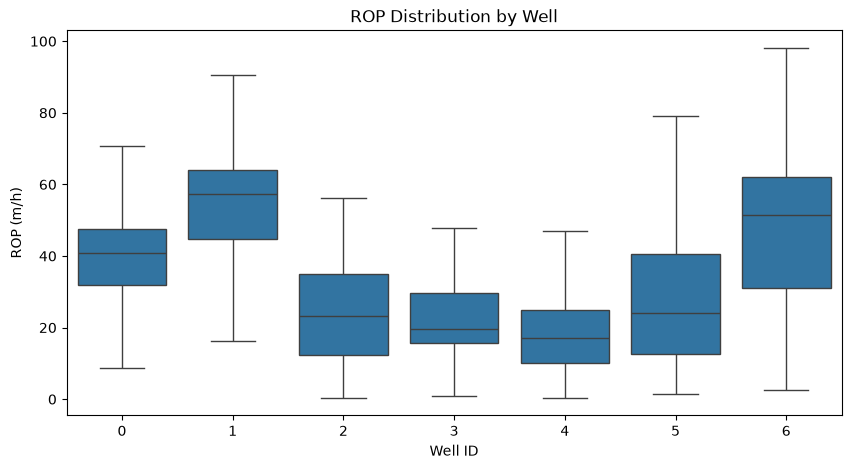

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=working_df,
    x="well_id",
    y="rop_m_per_h",
    showfliers=False
)

plt.title("ROP Distribution by Well")
plt.xlabel("Well ID")
plt.ylabel("ROP (m/h)")
plt.show()

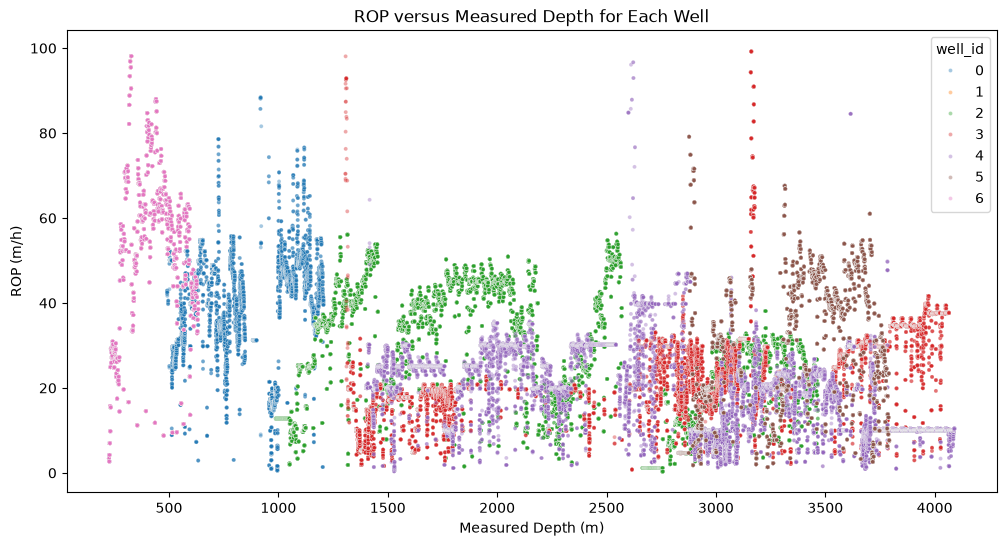

In [42]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=working_df,
    x="measured_depth_m",
    y="rop_m_per_h",
    hue="well_id",
    palette="tab10",
    s=8,
    alpha=0.4
)

plt.title("ROP versus Measured Depth for Each Well")
plt.xlabel("Measured Depth (m)")
plt.ylabel("ROP (m/h)")
plt.show()

In [44]:
working_df['rop_m_per_h'].value_counts()

rop_m_per_h
31.542838    1790
8.320000     1477
10.021824    1068
30.178858    1067
10.030054     782
             ... 
7.088429        1
10.426903       1
9.002268        1
8.031175        1
9.090000        1
Name: count, Length: 13613, dtype: int64

In [ ]:
(working_df['rop_m_per_h']==0).value_counts()

rop_m_per_h
False    198928
Name: count, dtype: int64

In [48]:
working_df['rop_m_per_h'].loc[working_df['rop_m_per_h'] ==0]

Series([], Name: rop_m_per_h, dtype: float64)

In [55]:
working_df.columns

Index(['measured_depth_m', 'wob_kkgf', 'standpipe_pressure_kpa',
       'surface_torque_knm', 'rop_m_per_h', 'rotary_speed_rpm', 'mud_flow_lpm',
       'mud_density_gcm3', 'diameter_mm', 'hookload_kkgf', 'tvd_m',
       'gamma_gapi', 'well_id', 'source_file'],
      dtype='str')

In [56]:
working_df[['measured_depth_m', 'wob_kkgf', 'standpipe_pressure_kpa',
       'surface_torque_knm', 'rop_m_per_h', 'rotary_speed_rpm', 'mud_flow_lpm',
       'mud_density_gcm3', 'diameter_mm', 'hookload_kkgf', 'tvd_m',
       'gamma_gapi', 'well_id']].skew()

measured_depth_m         -0.345659
wob_kkgf                  0.906045
standpipe_pressure_kpa   -0.129656
surface_torque_knm        0.529987
rop_m_per_h               0.998834
rotary_speed_rpm          0.457813
mud_flow_lpm              0.322860
mud_density_gcm3          1.062461
diameter_mm               0.626293
hookload_kkgf            -1.118999
tvd_m                    -0.690687
gamma_gapi                0.903386
well_id                  -0.219567
dtype: float64

# Train test SPlit

In [65]:
test_well_id = 2

train_df = working_df.loc[
    working_df["well_id"] != test_well_id
].copy()

test_df = working_df.loc[
    working_df["well_id"] == test_well_id
].copy()

In [66]:
drop_columns = ["rop_m_per_h", "well_id", "source_file"]

X_train = train_df.drop(columns=drop_columns)
y_train = train_df["rop_m_per_h"]

X_test = test_df.drop(columns=drop_columns)
y_test = test_df["rop_m_per_h"]


In [67]:

groups_train = train_df["well_id"]
groups_train

0         0
1         0
2         0
3         0
4         0
         ..
198923    6
198924    6
198925    6
198926    6
198927    6
Name: well_id, Length: 151283, dtype: int64

In [68]:
print("Training wells:", sorted(train_df["well_id"].unique()))
print("Test well:", sorted(test_df["well_id"].unique()))

print("Training rows:", len(train_df))
print("Test rows:", len(test_df))

Training wells: [np.int64(0), np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Test well: [np.int64(2)]
Training rows: 151283
Test rows: 47645


# Model Build

In [74]:
X_train.isna().sum()
y_train.isna().sum()
X_test.isna().sum()
y_test.isna().sum()

np.int64(0)

In [85]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)
import pandas as pd

In [87]:
X = working_df.drop(
    columns=[
        "rop_m_per_h",
        "well_id",
        "source_file"
    ]
)

y = working_df["rop_m_per_h"]

groups = working_df["well_id"]

In [88]:
logo = LeaveOneGroupOut()

well_scores = []
all_predictions = []

for train_idx, test_idx in logo.split(X, y, groups=groups):

    X_fold_train = X.iloc[train_idx]
    X_fold_test = X.iloc[test_idx]

    y_fold_train = y.iloc[train_idx]
    y_fold_test = y.iloc[test_idx]

    test_well = groups.iloc[test_idx].unique()[0]

    rf_model = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(X_fold_train, y_fold_train)

    predictions = rf_model.predict(X_fold_test)

    mae = mean_absolute_error(
        y_fold_test,
        predictions
    )

    rmse = root_mean_squared_error(
        y_fold_test,
        predictions
    )

    r2 = r2_score(
        y_fold_test,
        predictions
    )

    wmape = (
        abs(y_fold_test.to_numpy() - predictions).sum()
        / abs(y_fold_test.to_numpy()).sum()
        * 100
    )

    well_scores.append({
        "test_well": test_well,
        "number_of_rows": len(y_fold_test),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "WMAPE_percent": wmape
    })

    fold_predictions = pd.DataFrame({
        "well_id": test_well,
        "actual_rop": y_fold_test.to_numpy(),
        "predicted_rop": predictions
    })

    all_predictions.append(fold_predictions)

In [89]:
rf_well_results = pd.DataFrame(well_scores)

rf_well_results

,test_well,number_of_rows,MAE,RMSE,R2,WMAPE_percent
0,0,13746,20.039716,25.138957,-3.411710,51.250700
1,1,6389,0.020594,0.234365,0.999786,0.037259
2,2,47645,15.759949,20.155591,-1.301719,64.140630
3,3,53041,10.265047,12.944507,-0.807763,47.575101
4,4,51708,10.164713,11.969332,-0.819505,58.666205
5,5,18548,15.231455,18.175973,-0.303820,57.517725
6,6,7851,9.572549,20.233136,-0.020709,19.983868


In [90]:
rf_predictions = pd.concat(
    all_predictions,
    ignore_index=True
)

overall_mae = mean_absolute_error(
    rf_predictions["actual_rop"],
    rf_predictions["predicted_rop"]
)

overall_rmse = root_mean_squared_error(
    rf_predictions["actual_rop"],
    rf_predictions["predicted_rop"]
)

overall_r2 = r2_score(
    rf_predictions["actual_rop"],
    rf_predictions["predicted_rop"]
)

overall_wmape = (
    (
        rf_predictions["actual_rop"]
        - rf_predictions["predicted_rop"]
    ).abs().sum()
    / rf_predictions["actual_rop"].abs().sum()
    * 100
)

print("Overall MAE:", overall_mae)
print("Overall RMSE:", overall_rmse)
print("Overall R²:", overall_r2)
print("Overall WMAPE:", overall_wmape)

Overall MAE: 12.337191049227378
Overall RMSE: 16.42703614570306
Overall R²: -0.18557849160067819
Overall WMAPE: 49.391387838004924
